# Strong Prompt Analysis: Responder Behavior Correction

This notebook analyzes the effect of **strong prompts** (behaviorally explicit D-Factor descriptions) vs. **original prompts** (abstract trait descriptions) on responder behavior in the Ultimatum Game.

**Key Finding**: Strong prompts shift responder D-correlations from negative/flat to positive, approaching human-like patterns.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import glob
import warnings
warnings.filterwarnings('ignore')

# Set style (matching paper_v2)
plt.rcParams['font.size'] = 9
plt.rcParams['font.family'] = 'sans-serif'

# Colors
color_orig = "#E74C3C"   # Red - Original prompts
color_strong = "#3498DB" # Blue - Strong prompts
color_human = "#2ECC71"  # Green - Human benchmark
ALPHA_FILL = 0.20

## Load and Prepare Data

In [37]:
# Load original data
ai_orig = pd.read_csv('data/aidata.csv')
human_df = pd.read_csv('data/hudata.csv')

# Map text D-levels to numeric for AI data
d_text_map = {'Low': 1, 'Low-Moderate': 2, 'Moderate': 3, 'Moderate-High': 4, 'High': 5}
ai_orig['d_num'] = ai_orig['d'].map(d_text_map)

# Human data has continuous d_numeric scores - bin into quintiles (1-5)
# Check if human data has categorical or continuous D
if 'd_numeric' in human_df.columns:
    # Continuous scores - bin into quintiles
    human_df['d_num'] = pd.qcut(human_df['d_numeric'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
    print("Human D-scores: continuous, binned into quintiles")
elif 'd' in human_df.columns:
    # Try mapping text labels
    human_df['d_num'] = human_df['d'].map(d_text_map)
    print("Human D-scores: categorical, mapped to 1-5")
else:
    print("WARNING: No D-factor column found in human data!")

# Models with strong prompt data
models_of_interest = ['dolphin3', 'llama3.2', 'qwen2.5', 'gemma3_4b', 'phi4']

print(f"Original AI data: {len(ai_orig):,} observations")
print(f"Human data: {len(human_df):,} observations")
print(f"Models with strong prompts: {models_of_interest}")

Human D-scores: continuous, binned into quintiles
Original AI data: 339,956 observations
Human data: 4,166 observations
Models with strong prompts: ['dolphin3', 'llama3.2', 'qwen2.5', 'gemma3_4b', 'phi4']


In [38]:
# Load strong prompt RAW data (not the summary file)
strong_combined = pd.read_csv('data/strong_prompt_raw_data.csv')

# Map text D-levels to numeric (same as ai_orig above)
strong_combined['d_num'] = strong_combined['d'].map(d_text_map)

# Compute prosocial indicator based on decisions
# Proposers: prosocial = fair offer (50-50 split)
# Responders: prosocial = accept offer
def extract_prosocial(row):
    """Extract prosocial behavior from q1_decision."""
    if pd.isna(row['q1_decision']):
        return np.nan
    
    decision = str(row['q1_decision']).strip().upper()
    
    if row['role'] == 'proposer':
        # Proposer: prosocial = offering 50-50 (decision A)
        # Decision format is typically "A" or "B"
        return 1.0 if 'A' in decision else 0.0
    else:  # responder
        # Responder: prosocial = accepting the offer
        # Decision format is typically "A" (accept) or "B" (reject)
        return 1.0 if 'A' in decision else 0.0

strong_combined['prosocial'] = strong_combined.apply(extract_prosocial, axis=1)

# Separate by role
strong_proposer = strong_combined[strong_combined['role'] == 'proposer'].copy()
strong_responder = strong_combined[strong_combined['role'] == 'responder'].copy()

print(f"✓ Strong prompt RAW data loaded: {len(strong_combined):,} observations")
print(f"  Proposers: {len(strong_proposer):,}")
print(f"  Responders: {len(strong_responder):,}")
print(f"  Columns: {', '.join(strong_combined.columns)}")

✓ Strong prompt RAW data loaded: 82,083 observations
  Proposers: 50,000
  Responders: 32,083
  Columns: agent_id, token, d, d_description, q1_full_response, q1_decision, q1_text, model, temperature, role, d_num, prosocial


## Main Result: D-Correlation Shift (Responders)

In [39]:
def compute_d_correlation(df, d_col='d_num', prosocial_col='prosocial'):
    """Compute point-biserial correlation between D-level and prosocial behavior."""
    valid = df[[d_col, prosocial_col]].dropna()
    if len(valid) < 5 or valid[prosocial_col].nunique() < 2:
        return np.nan
    return np.corrcoef(valid[d_col], valid[prosocial_col])[0, 1]

# Compute correlations for each model
results = []
for model in models_of_interest:
    # Original responder
    orig_resp = ai_orig[(ai_orig['model'] == model) & (ai_orig['role'] == 'responder')]
    orig_corr = compute_d_correlation(orig_resp)
    
    # Strong responder
    strong_resp = strong_responder[strong_responder['model'] == model]
    strong_corr = compute_d_correlation(strong_resp)
    
    results.append({
        'model': model,
        'orig_corr': orig_corr,
        'strong_corr': strong_corr,
        'delta': strong_corr - orig_corr if not (np.isnan(orig_corr) or np.isnan(strong_corr)) else np.nan,
        'orig_accept': orig_resp['prosocial'].mean(),
        'strong_accept': strong_resp['prosocial'].mean()
    })

results_df = pd.DataFrame(results)

# Human benchmark - use binned d_num
human_resp = human_df[human_df['role'] == 'responder']
human_corr = compute_d_correlation(human_resp, d_col='d_num')

# Also compute with continuous d_numeric for reference if available
if 'd_numeric' in human_df.columns:
    human_corr_continuous = compute_d_correlation(human_resp, d_col='d_numeric')
    print(f"Human benchmark (continuous D): {human_corr_continuous:+.3f}")
    
print("\nRESPONDER D-CORRELATIONS")
print("="*60)
print(f"Human benchmark (binned D1-D5): {human_corr:+.3f}")
print("="*60)
print(results_df.round(3).to_string(index=False))
print("\nMean shift:", results_df['delta'].dropna().mean().round(3))

Human benchmark (continuous D): -0.365

RESPONDER D-CORRELATIONS
Human benchmark (binned D1-D5): -0.305
    model  orig_corr  strong_corr  delta  orig_accept  strong_accept
 dolphin3     -0.071        0.504  0.575        0.955          0.283
 llama3.2     -0.138        0.117  0.255        0.257          0.027
  qwen2.5     -0.685          NaN    NaN        0.711            NaN
gemma3_4b        NaN        0.354    NaN        1.000          0.800
     phi4     -0.254        0.861  1.115        0.969          0.586

Mean shift: 0.648


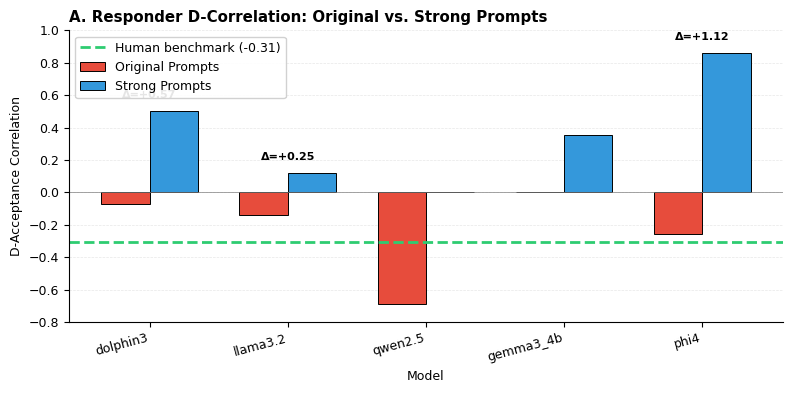

In [40]:
# FIGURE 1: D-Correlation Comparison (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(models_of_interest))
width = 0.35

# Bars
bars_orig = ax.bar(x - width/2, results_df['orig_corr'].fillna(0), width, 
                   label='Original Prompts', color=color_orig, edgecolor='black', linewidth=0.7)
bars_strong = ax.bar(x + width/2, results_df['strong_corr'].fillna(0), width,
                     label='Strong Prompts', color=color_strong, edgecolor='black', linewidth=0.7)

# Human benchmark line (only if valid)
if not np.isnan(human_corr):
    ax.axhline(y=human_corr, color=color_human, linestyle='--', linewidth=2, 
               label=f'Human benchmark ({human_corr:+.2f})')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Formatting
ax.set_xlabel('Model', fontweight='medium')
ax.set_ylabel('D-Acceptance Correlation', fontweight='medium')
ax.set_title('A. Responder D-Correlation: Original vs. Strong Prompts', fontweight='bold', loc='left')
ax.set_xticks(x)
ax.set_xticklabels(models_of_interest, rotation=15, ha='right')
ax.set_ylim(-0.8, 1.0)
ax.legend(loc='upper left', framealpha=0.9)

ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add delta annotations
for i, (idx, row) in enumerate(results_df.iterrows()):
    if not np.isnan(row['delta']):
        ax.annotate(f"Δ={row['delta']:+.2f}", 
                    xy=(i, max(row['orig_corr'], row['strong_corr']) + 0.08),
                    ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
#plt.savefig('strong_prompt_correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Acceptance Rates by D-Level

In [41]:
# Compute acceptance rates by D-level for each condition
def get_rates_by_d(df, models):
    rates = df[df['model'].isin(models)].groupby('d_num')['prosocial'].agg(['mean', 'std', 'count'])
    rates['se'] = rates['std'] / np.sqrt(rates['count'])
    return rates

orig_rates = get_rates_by_d(ai_orig[ai_orig['role'] == 'responder'], models_of_interest)
strong_rates = get_rates_by_d(strong_responder, models_of_interest)
human_rates = human_df[human_df['role'] == 'responder'].groupby('d_num')['prosocial'].agg(['mean', 'std', 'count'])
human_rates['se'] = human_rates['std'] / np.sqrt(human_rates['count'])

# Reindex all to ensure we have D1-D5 (indices 1-5)
d_index = [1, 2, 3, 4, 5]
orig_rates = orig_rates.reindex(d_index)
strong_rates = strong_rates.reindex(d_index)
human_rates = human_rates.reindex(d_index)

print("Acceptance Rates by D-Level (Responders)")
print("="*60)

# Create comparison table with proper handling
comparison = pd.DataFrame({
    'D-Level': ['D1', 'D2', 'D3', 'D4', 'D5'],
    'Human': (human_rates['mean'].values * 100).round(1) if not human_rates['mean'].isna().all() else [np.nan]*5,
    'Original': (orig_rates['mean'].values * 100).round(1),
    'Strong': (strong_rates['mean'].values * 100).round(1)
})
print(comparison.to_string(index=False))

Acceptance Rates by D-Level (Responders)
D-Level  Human  Original  Strong
     D1   94.7      84.4    31.1
     D2   89.7      83.9     0.0
     D3   87.1      89.6    62.8
     D4   81.8      70.9    86.0
     D5   57.7      60.6    69.3


## Per-Model Breakdown

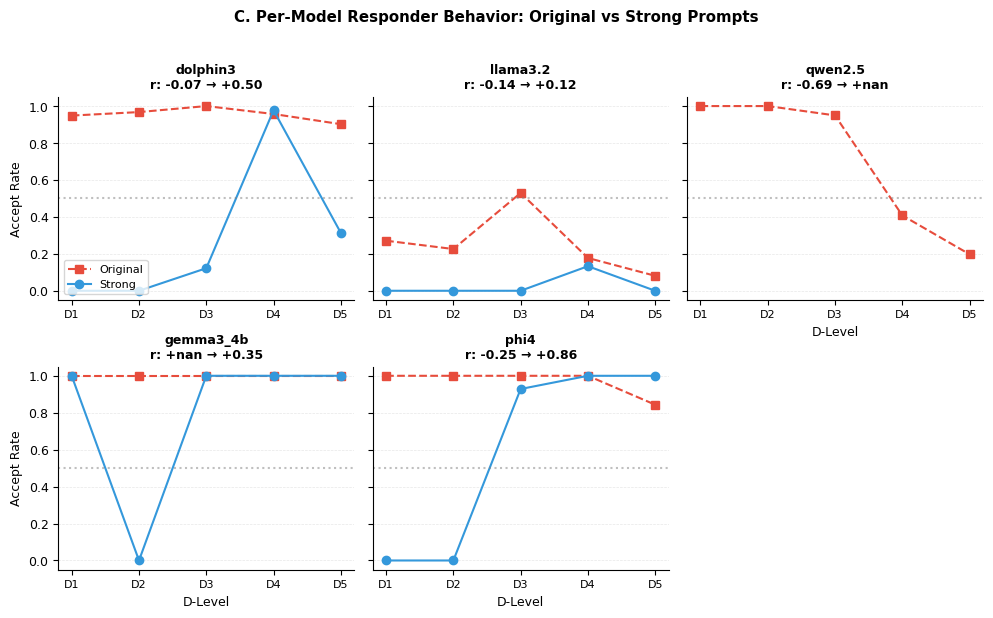

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharey=True)
axes = axes.flatten()

for i, model in enumerate(models_of_interest):
    ax = axes[i]
    
    # Original data for this model
    orig_model = ai_orig[(ai_orig['model'] == model) & (ai_orig['role'] == 'responder')]
    orig_by_d = orig_model.groupby('d_num')['prosocial'].mean()
    
    # Strong data for this model
    strong_model = strong_responder[strong_responder['model'] == model]
    strong_by_d = strong_model.groupby('d_num')['prosocial'].mean()
    
    # Plot
    ax.plot(d_levels, [orig_by_d.get(d, np.nan) for d in d_levels], 
            's--', color=color_orig, linewidth=1.5, markersize=6, label='Original')
    ax.plot(d_levels, [strong_by_d.get(d, np.nan) for d in d_levels],
            'o-', color=color_strong, linewidth=1.5, markersize=6, label='Strong')
    
    # Compute correlations for title
    orig_corr = compute_d_correlation(orig_model)
    strong_corr = compute_d_correlation(strong_model)
    
    ax.set_title(f'{model}\nr: {orig_corr:+.2f} → {strong_corr:+.2f}', fontweight='bold', fontsize=9)
    ax.set_xticks(d_levels)
    ax.set_xticklabels(['D1', 'D2', 'D3', 'D4', 'D5'], fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    
    ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='lower left', fontsize=8)
    if i % 3 == 0:
        ax.set_ylabel('Accept Rate')
    if i >= 2:
        ax.set_xlabel('D-Level')

# Hide empty subplot
axes[5].set_visible(False)

fig.suptitle('C. Per-Model Responder Behavior: Original vs Strong Prompts', 
             fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('strong_prompt_per_model.png', dpi=150, bbox_inches='tight')

## Proposer Analysis (Control Check)

Do strong prompts also affect proposer behavior? (They should show similar patterns since proposers already worked well.)

In [43]:
# Proposer comparison
prop_results = []
for model in models_of_interest:
    orig_prop = ai_orig[(ai_orig['model'] == model) & (ai_orig['role'] == 'proposer')]
    strong_prop = strong_proposer[strong_proposer['model'] == model]
    
    prop_results.append({
        'model': model,
        'orig_corr': compute_d_correlation(orig_prop),
        'strong_corr': compute_d_correlation(strong_prop),
        'orig_fair': orig_prop['prosocial'].mean(),
        'strong_fair': strong_prop['prosocial'].mean()
    })

prop_df = pd.DataFrame(prop_results)
prop_df['delta'] = prop_df['strong_corr'] - prop_df['orig_corr']

print("PROPOSER D-CORRELATIONS (Control Check)")
print("="*60)
print("Both conditions should show NEGATIVE correlations (higher D = less fair)")
print("="*60)
print(prop_df.round(3).to_string(index=False))

PROPOSER D-CORRELATIONS (Control Check)
Both conditions should show NEGATIVE correlations (higher D = less fair)
    model  orig_corr  strong_corr  orig_fair  strong_fair  delta
 dolphin3     -0.232       -0.739      0.938        0.678 -0.506
 llama3.2     -0.336       -0.521      0.927        0.860 -0.185
  qwen2.5     -0.851       -0.853      0.386        0.387 -0.001
gemma3_4b     -0.707          NaN      0.200        0.000    NaN
     phi4     -0.717       -0.866      0.219        0.400 -0.149


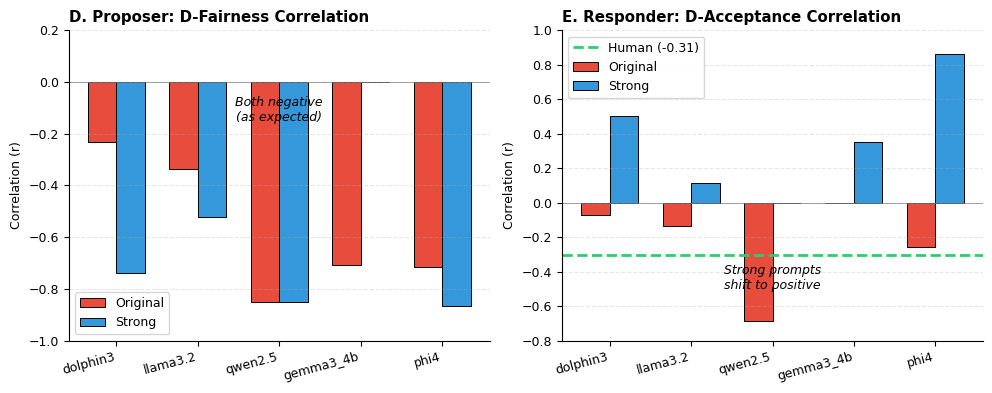

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: Proposer
x = np.arange(len(models_of_interest))
width = 0.35

ax1.bar(x - width/2, prop_df['orig_corr'].fillna(0), width,
        label='Original', color=color_orig, edgecolor='black', linewidth=0.7)
ax1.bar(x + width/2, prop_df['strong_corr'].fillna(0), width,
        label='Strong', color=color_strong, edgecolor='black', linewidth=0.7)
ax1.axhline(0, color='gray', linewidth=0.5)

ax1.set_title('D. Proposer: D-Fairness Correlation', fontweight='bold', loc='left')
ax1.set_ylabel('Correlation (r)', fontweight='medium')
ax1.set_xticks(x)
ax1.set_xticklabels(models_of_interest, rotation=15, ha='right')
ax1.set_ylim(-1, 0.2)
ax1.legend(loc='lower left')
ax1.yaxis.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.annotate('Both negative\n(as expected)', xy=(2, -0.15), ha='center', fontsize=9, style='italic')

# Right: Responder
ax2.bar(x - width/2, results_df['orig_corr'].fillna(0), width,
        label='Original', color=color_orig, edgecolor='black', linewidth=0.7)
ax2.bar(x + width/2, results_df['strong_corr'].fillna(0), width,
        label='Strong', color=color_strong, edgecolor='black', linewidth=0.7)
# Human benchmark line only if valid
if not np.isnan(human_corr):
    ax2.axhline(human_corr, color=color_human, linestyle='--', linewidth=2, label=f'Human ({human_corr:+.2f})')
ax2.axhline(0, color='gray', linewidth=0.5)

ax2.set_title('E. Responder: D-Acceptance Correlation', fontweight='bold', loc='left')
ax2.set_ylabel('Correlation (r)', fontweight='medium')
ax2.set_xticks(x)
ax2.set_xticklabels(models_of_interest, rotation=15, ha='right')
ax2.set_ylim(-0.8, 1.0)
ax2.legend(loc='upper left')
ax2.yaxis.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.annotate('Strong prompts\nshift to positive', xy=(2, -0.5), ha='center', fontsize=9, style='italic')

plt.tight_layout()
#plt.savefig('strong_prompt_summary.png', dpi=150, bbox_inches='tight')

## Statistical Summary

In [45]:
# Paired comparison statistics
valid_deltas = results_df['delta'].dropna()

print("="*60)
print("STATISTICAL SUMMARY: RESPONDER D-CORRELATIONS")
print("="*60)
print(f"\nOriginal prompts:")
print(f"  Mean r = {results_df['orig_corr'].mean():.3f} (SD = {results_df['orig_corr'].std():.3f})")
print(f"\nStrong prompts:")
print(f"  Mean r = {results_df['strong_corr'].mean():.3f} (SD = {results_df['strong_corr'].std():.3f})")
print(f"\nMean shift (Δr):")
print(f"  {valid_deltas.mean():+.3f} (SD = {valid_deltas.std():.3f})")
print(f"\nHuman benchmark: r = {human_corr:+.3f}" if not np.isnan(human_corr) else "\nHuman benchmark: N/A (insufficient data)")

# One-sample t-test: is the shift significantly > 0?
if len(valid_deltas) >= 3:
    t_stat, p_val = stats.ttest_1samp(valid_deltas, 0)
    print(f"\nOne-sample t-test (shift > 0):")
    print(f"  t = {t_stat:.2f}, p = {p_val:.4f}")

STATISTICAL SUMMARY: RESPONDER D-CORRELATIONS

Original prompts:
  Mean r = -0.287 (SD = 0.276)

Strong prompts:
  Mean r = 0.459 (SD = 0.312)

Mean shift (Δr):
  +0.648 (SD = 0.435)

Human benchmark: r = -0.305

One-sample t-test (shift > 0):
  t = 2.58, p = 0.1231


## 9. Both Roles Comparison

This figure shows the complete picture of strong vs. original prompts for **both proposers and responders**.


SUMMARY

PROPOSER:
  Human: r = -0.234
  Original: r = -0.569
  Strong: r = -0.745
  → Both negative (as expected)

RESPONDER:
  Human: r = -0.305
  Original: r = -0.287
  Strong: r = +0.459
  → Strong prompts shifted OPPOSITE to human benchmark!


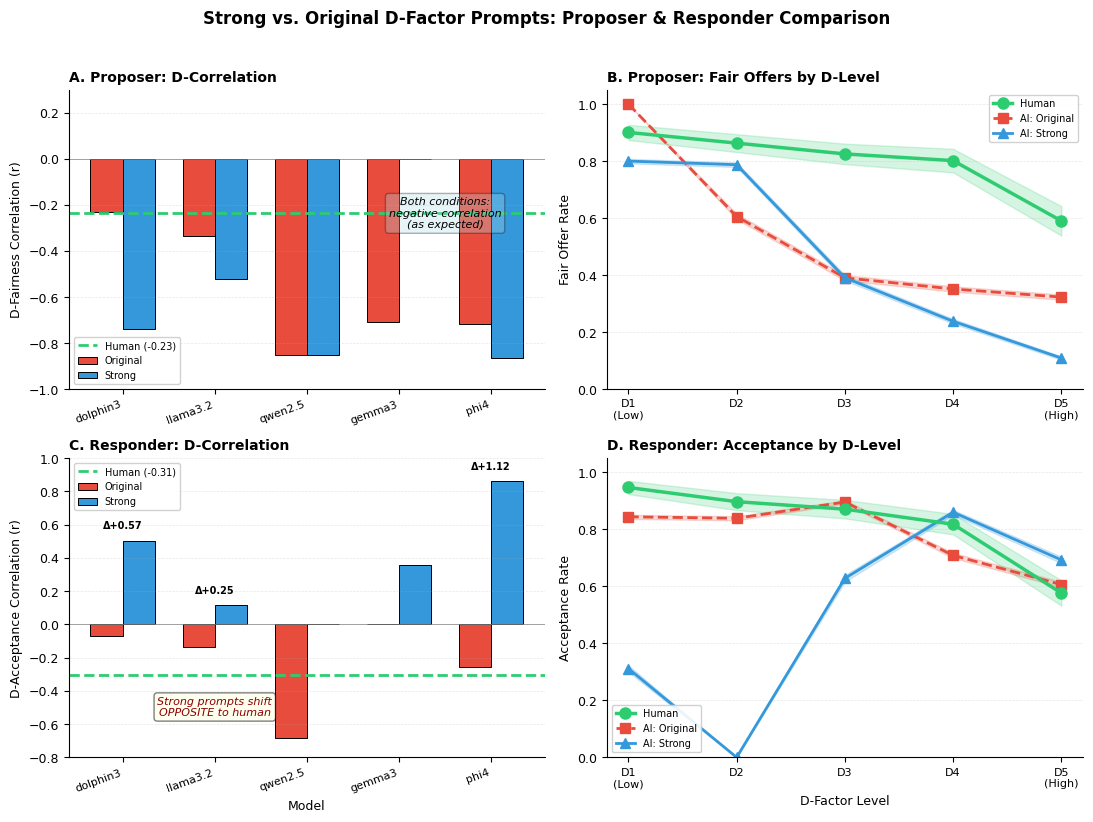

In [46]:
# Compute proposer rates by D-level
def get_rates_by_d_role(df, models, role):
    subset = df[(df['model'].isin(models)) & (df['role'] == role)]
    rates = subset.groupby('d_num')['prosocial'].agg(['mean', 'std', 'count'])
    rates['se'] = rates['std'] / np.sqrt(rates['count'])
    return rates.reindex([1, 2, 3, 4, 5])

# Proposer rates
prop_orig_rates = get_rates_by_d_role(ai_orig, models_of_interest, 'proposer')
prop_strong_rates = strong_proposer.groupby('d_num')['prosocial'].agg(['mean', 'std', 'count'])
prop_strong_rates['se'] = prop_strong_rates['std'] / np.sqrt(prop_strong_rates['count'])
prop_strong_rates = prop_strong_rates.reindex([1, 2, 3, 4, 5])

human_prop_rates = human_df[human_df['role'] == 'proposer'].groupby('d_num')['prosocial'].agg(['mean', 'std', 'count'])
human_prop_rates['se'] = human_prop_rates['std'] / np.sqrt(human_prop_rates['count'])
human_prop_rates = human_prop_rates.reindex([1, 2, 3, 4, 5])

# Responder rates (already computed above as orig_rates, strong_rates, human_rates)
resp_orig_rates = orig_rates
resp_strong_rates = strong_rates
human_resp_rates = human_rates

# Human correlations
human_prop = human_df[human_df['role'] == 'proposer']
human_prop_corr = compute_d_correlation(human_prop)

# Model labels for cleaner display
model_labels = ['dolphin3', 'llama3.2', 'qwen2.5', 'gemma3', 'phi4']

# ---- CREATE THE 2x2 FIGURE ----
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

d_levels = [1, 2, 3, 4, 5]
d_labels = ['D1\n(Low)', 'D2', 'D3', 'D4', 'D5\n(High)']
x = np.arange(len(models_of_interest))
width = 0.35

# ---- TOP ROW: PROPOSER ----
# Panel A: Proposer D-Correlation
ax1 = axes[0, 0]
ax1.bar(x - width/2, prop_df['orig_corr'].fillna(0), width, 
        label='Original', color=color_orig, edgecolor='black', linewidth=0.7)
ax1.bar(x + width/2, prop_df['strong_corr'].fillna(0), width,
        label='Strong', color=color_strong, edgecolor='black', linewidth=0.7)
if not np.isnan(human_prop_corr):
    ax1.axhline(y=human_prop_corr, color=color_human, linestyle='--', linewidth=2, 
                label=f'Human ({human_prop_corr:+.2f})')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

ax1.set_ylabel('D-Fairness Correlation (r)', fontweight='medium')
ax1.set_title('A. Proposer: D-Correlation', fontweight='bold', fontsize=10, loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=8)
ax1.set_ylim(-1.0, 0.3)
ax1.legend(loc='lower left', fontsize=7, framealpha=0.9)
ax1.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.annotate('Both conditions:\nnegative correlation\n(as expected)', 
             xy=(3.5, -0.3), ha='center', fontsize=8, style='italic',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

# Panel B: Proposer Rates by D-Level
ax2 = axes[0, 1]
if not human_prop_rates['mean'].isna().all():
    ax2.plot(d_levels, human_prop_rates['mean'].values, 'o-', color=color_human, 
             linewidth=2.5, markersize=8, label='Human', zorder=3)
    ax2.fill_between(d_levels, 
                     human_prop_rates['mean'].values - 1.96*human_prop_rates['se'].values,
                     human_prop_rates['mean'].values + 1.96*human_prop_rates['se'].values,
                     color=color_human, alpha=ALPHA_FILL)

ax2.plot(d_levels, prop_orig_rates['mean'].values, 's--', color=color_orig,
         linewidth=2, markersize=7, label='AI: Original', zorder=2)
ax2.fill_between(d_levels,
                 prop_orig_rates['mean'].values - 1.96*prop_orig_rates['se'].values,
                 prop_orig_rates['mean'].values + 1.96*prop_orig_rates['se'].values,
                 color=color_orig, alpha=ALPHA_FILL)

ax2.plot(d_levels, prop_strong_rates['mean'].values, '^-', color=color_strong,
         linewidth=2, markersize=7, label='AI: Strong', zorder=2)
ax2.fill_between(d_levels,
                 prop_strong_rates['mean'].values - 1.96*prop_strong_rates['se'].values,
                 prop_strong_rates['mean'].values + 1.96*prop_strong_rates['se'].values,
                 color=color_strong, alpha=ALPHA_FILL)

ax2.set_ylabel('Fair Offer Rate', fontweight='medium')
ax2.set_title('B. Proposer: Fair Offers by D-Level', fontweight='bold', fontsize=10, loc='left')
ax2.set_xticks(d_levels)
ax2.set_xticklabels(d_labels, fontsize=8)
ax2.set_ylim(0, 1.05)
ax2.set_xlim(0.8, 5.2)
ax2.legend(loc='upper right', fontsize=7, framealpha=0.9)
ax2.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ---- BOTTOM ROW: RESPONDER ----
# Panel C: Responder D-Correlation
ax3 = axes[1, 0]
ax3.bar(x - width/2, results_df['orig_corr'].fillna(0), width, 
        label='Original', color=color_orig, edgecolor='black', linewidth=0.7)
ax3.bar(x + width/2, results_df['strong_corr'].fillna(0), width,
        label='Strong', color=color_strong, edgecolor='black', linewidth=0.7)
if not np.isnan(human_corr):
    ax3.axhline(y=human_corr, color=color_human, linestyle='--', linewidth=2, 
                label=f'Human ({human_corr:+.2f})')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

ax3.set_xlabel('Model', fontweight='medium')
ax3.set_ylabel('D-Acceptance Correlation (r)', fontweight='medium')
ax3.set_title('C. Responder: D-Correlation', fontweight='bold', fontsize=10, loc='left')
ax3.set_xticks(x)
ax3.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=8)
ax3.set_ylim(-0.8, 1.0)
ax3.legend(loc='upper left', fontsize=7, framealpha=0.9)
ax3.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add delta annotations for responder
for i, row in results_df.iterrows():
    if not np.isnan(row['delta']):
        y_pos = max(row['orig_corr'], row['strong_corr']) + 0.07
        ax3.annotate(f"Δ{row['delta']:+.2f}", xy=(i, y_pos), ha='center', fontsize=7, fontweight='bold')

ax3.annotate('Strong prompts shift\nOPPOSITE to human', 
             xy=(1, -0.55), ha='center', fontsize=8, style='italic', color='darkred',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# Panel D: Responder Rates by D-Level
ax4 = axes[1, 1]
if not human_resp_rates['mean'].isna().all():
    ax4.plot(d_levels, human_resp_rates['mean'].values, 'o-', color=color_human, 
             linewidth=2.5, markersize=8, label='Human', zorder=3)
    ax4.fill_between(d_levels, 
                     human_resp_rates['mean'].values - 1.96*human_resp_rates['se'].values,
                     human_resp_rates['mean'].values + 1.96*human_resp_rates['se'].values,
                     color=color_human, alpha=ALPHA_FILL)

ax4.plot(d_levels, resp_orig_rates['mean'].values, 's--', color=color_orig,
         linewidth=2, markersize=7, label='AI: Original', zorder=2)
ax4.fill_between(d_levels,
                 resp_orig_rates['mean'].values - 1.96*resp_orig_rates['se'].values,
                 resp_orig_rates['mean'].values + 1.96*resp_orig_rates['se'].values,
                 color=color_orig, alpha=ALPHA_FILL)

ax4.plot(d_levels, resp_strong_rates['mean'].values, '^-', color=color_strong,
         linewidth=2, markersize=7, label='AI: Strong', zorder=2)
ax4.fill_between(d_levels,
                 resp_strong_rates['mean'].values - 1.96*resp_strong_rates['se'].values,
                 resp_strong_rates['mean'].values + 1.96*resp_strong_rates['se'].values,
                 color=color_strong, alpha=ALPHA_FILL)

ax4.set_xlabel('D-Factor Level', fontweight='medium')
ax4.set_ylabel('Acceptance Rate', fontweight='medium')
ax4.set_title('D. Responder: Acceptance by D-Level', fontweight='bold', fontsize=10, loc='left')
ax4.set_xticks(d_levels)
ax4.set_xticklabels(d_labels, fontsize=8)
ax4.set_ylim(0, 1.05)
ax4.set_xlim(0.8, 5.2)
ax4.legend(loc='lower left', fontsize=7, framealpha=0.9)
ax4.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Overall title
fig.suptitle('Strong vs. Original D-Factor Prompts: Proposer & Responder Comparison', 
             fontweight='bold', fontsize=12, y=1.02)

plt.tight_layout()
#plt.savefig('strong_prompt_both_roles.png', dpi=300, bbox_inches='tight', facecolor='white')

# Print summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\nPROPOSER:")
print(f"  Human: r = {human_prop_corr:+.3f}")
print(f"  Original: r = {prop_df['orig_corr'].mean():+.3f}")
print(f"  Strong: r = {prop_df['strong_corr'].mean():+.3f}")
print(f"  → Both negative (as expected)")

print(f"\nRESPONDER:")
print(f"  Human: r = {human_corr:+.3f}")
print(f"  Original: r = {results_df['orig_corr'].mean():+.3f}")
print(f"  Strong: r = {results_df['strong_corr'].mean():+.3f}")
print(f"  → Strong prompts shifted OPPOSITE to human benchmark!")